# 🌍 Global Land Temperature Analysis
**Dataset:** GlobalLandTemperaturesByCity  
**Author:** Data Science Team  
**Objective:** End-to-end EDA — Data Quality → Feature Engineering → Trend Analysis → Geo-visualization

---

## 0. Environment Setup

In [2]:
# ─── Core ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Stats ───────────────────────────────────────────────
from scipy import stats

# ─── Display config ──────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# ─── Global plot theme ───────────────────────────────────
PALETTE   = ['#E63946', '#457B9D', '#F4A261', '#2A9D8F', '#264653', '#E9C46A']
DARK_BG   = '#0D1117'
GRID_CLR  = '#21262D'
TEXT_CLR  = '#C9D1D9'
ACCENT    = '#E63946'

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : '#161B22',
    'axes.edgecolor'   : GRID_CLR,
    'axes.labelcolor'  : TEXT_CLR,
    'axes.titlecolor'  : 'white',
    'xtick.color'      : TEXT_CLR,
    'ytick.color'      : TEXT_CLR,
    'grid.color'       : GRID_CLR,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'text.color'       : TEXT_CLR,
    'font.family'      : 'monospace',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print('✅ Environment ready.')

✅ Environment ready.


---
## 1. Data Ingestion

In [3]:
FILE_PATH = "../data/GlobalLandTemperaturesByCity.csv"

df_raw = pd.read_csv(FILE_PATH, nrows=100_000)

print(f"Shape        : {df_raw.shape}")
print(f"Memory usage : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df_raw.head()

Shape        : (100000, 7)
Memory usage : 30.12 MB


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.0680,1.7370,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


---
## 2. Data Quality Report  
> *MNC standard: always quantify data quality before touching a single row.*

In [4]:
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    """Comprehensive DQ report — dtypes, nulls, cardinality, sample values."""
    report = pd.DataFrame(index=df.columns)
    report['dtype']        = df.dtypes
    report['non_null']     = df.notnull().sum()
    report['null_count']   = df.isnull().sum()
    report['null_%']       = (df.isnull().mean() * 100).round(2)
    report['unique']       = df.nunique()
    report['cardinality%'] = (df.nunique() / len(df) * 100).round(2)
    report['sample']       = [df[c].dropna().iloc[0] if df[c].notnull().any() else 'ALL NULL'
                              for c in df.columns]
    return report


dq = data_quality_report(df_raw)
display(dq.style
    .background_gradient(subset=['null_%'], cmap='Reds')
    .background_gradient(subset=['cardinality%'], cmap='Blues')
    .format({'null_%': '{:.2f}%', 'cardinality%': '{:.2f}%'})
    .set_caption('📋 Data Quality Report')
)

,dtype,non_null,null_count,null_%,unique,cardinality%,sample
dt,object,100000,0,0.00%,3239,3.24%,1743-11-01
AverageTemperature,float64,95726,4274,4.27%,39041,39.04%,6.068000
AverageTemperatureUncertainty,float64,95726,4274,4.27%,5450,5.45%,1.737000
City,object,100000,0,0.00%,42,0.04%,Århus
Country,object,100000,0,0.00%,26,0.03%,Denmark
Latitude,object,100000,0,0.00%,25,0.02%,57.05N
Longitude,object,100000,0,0.00%,40,0.04%,10.33E


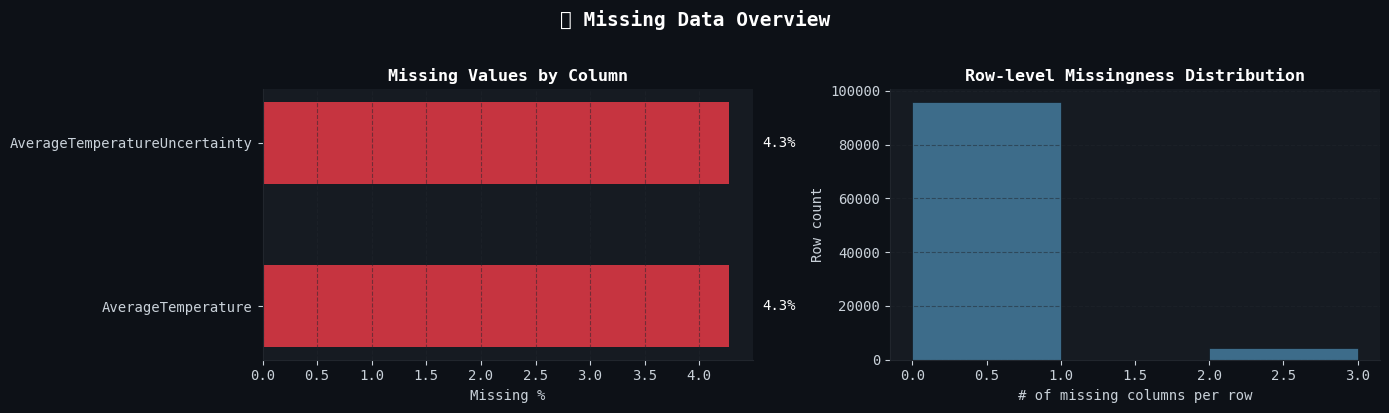

In [5]:
# ── Missing-value heatmap ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of null %
null_pct = df_raw.isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=True)

axes[0].barh(null_pct.index, null_pct.values, color=ACCENT, alpha=0.85, height=0.5)
for i, v in enumerate(null_pct.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', color='white', fontsize=10)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values by Column', fontweight='bold')
axes[0].grid(axis='x')

# Row-level missingness distribution
row_null = df_raw.isnull().sum(axis=1)
axes[1].hist(row_null, bins=range(0, row_null.max() + 2), color='#457B9D',
             alpha=0.85, edgecolor=DARK_BG, linewidth=0.5)
axes[1].set_xlabel('# of missing columns per row')
axes[1].set_ylabel('Row count')
axes[1].set_title('Row-level Missingness Distribution', fontweight='bold')
axes[1].grid(axis='y')

plt.suptitle('🔍 Missing Data Overview', fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning & Feature Engineering

In [6]:
df = df_raw.copy()

# ── 3.1 Date parsing ──────────────────────────────────────────────────────────
df['dt'] = pd.to_datetime(df['dt'])

# ── 3.2 Impute temperature with country-level median (robust to outliers) ─────
for col in ['AverageTemperature', 'AverageTemperatureUncertainty']:
    df[col] = df.groupby('Country')[col].transform(
        lambda x: x.fillna(x.median())
    )

# ── 3.3 Coordinate parsing ────────────────────────────────────────────────────
def parse_coord(val):
    if pd.isna(val) or not isinstance(val, str):
        return np.nan
    sign = -1 if val[-1] in ('S', 'W') else 1
    return sign * float(val[:-1])

df['Latitude']  = df['Latitude'].apply(parse_coord)
df['Longitude'] = df['Longitude'].apply(parse_coord)

# ── 3.4 Temporal features ─────────────────────────────────────────────────────
df['Year']    = df['dt'].dt.year
df['Month']   = df['dt'].dt.month
df['Decade']  = (df['Year'] // 10) * 10
df['Season']  = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

# ── 3.5 Hemisphere ────────────────────────────────────────────────────────────
df['Hemisphere'] = df['Latitude'].apply(
    lambda lat: 'Northern' if lat >= 0 else 'Southern' if not np.isnan(lat) else 'Unknown'
)

print(f'Clean shape : {df.shape}')
print(f'Date range  : {df["dt"].min().date()}  →  {df["dt"].max().date()}')
print(f'Countries   : {df["Country"].nunique()}')
print(f'Cities      : {df["City"].nunique()}')
df.head(3)

Clean shape : (100000, 12)
Date range  : 1743-11-01  →  2013-09-01
Countries   : 26
Cities      : 42


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year,Month,Decade,Season,Hemisphere
0,1743-11-01,6.0680,1.7370,Århus,Denmark,57.0500,10.3300,1743,11,1740,Autumn,Northern
1,1743-12-01,7.0550,0.6370,Århus,Denmark,57.0500,10.3300,1743,12,1740,Winter,Northern
2,1744-01-01,7.0550,0.6370,Århus,Denmark,57.0500,10.3300,1744,1,1740,Winter,Northern


---
## 4. Univariate Analysis

In [7]:
# ── Statistical summary of key numerical columns ──────────────────────────────
num_cols = ['AverageTemperature', 'AverageTemperatureUncertainty']
stats_df = df[num_cols].describe().T
stats_df['skew']     = df[num_cols].skew()
stats_df['kurtosis'] = df[num_cols].kurtosis()
stats_df['IQR']      = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)

display(stats_df.style
    .background_gradient(cmap='coolwarm', subset=['mean','std','skew'])
    .format('{:.3f}')
    .set_caption('📊 Descriptive Statistics + Shape Diagnostics')
)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,IQR
AverageTemperature,100000.000,17.269,11.287,-31.138,10.528,19.778,26.310,38.531,-1.085,1.029,15.782
AverageTemperatureUncertainty,100000.000,1.038,1.117,0.049,0.365,0.624,1.336,15.030,3.244,16.603,0.971


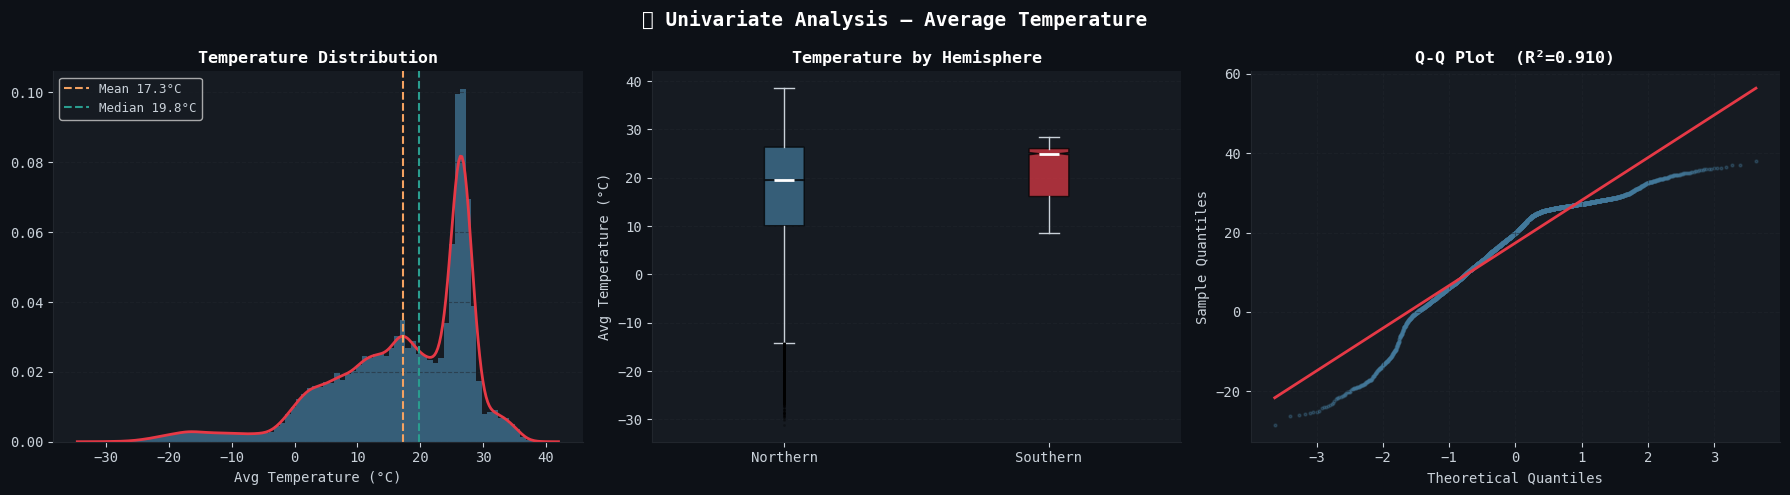

In [8]:
# ── Distribution deep-dive ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

temp = df['AverageTemperature'].dropna()

# Histogram + KDE
axes[0].hist(temp, bins=80, color='#457B9D', alpha=0.7, density=True, edgecolor='none')
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 300)
kde = stats.gaussian_kde(temp)
axes[0].plot(x, kde(x), color=ACCENT, linewidth=2)
axes[0].axvline(temp.mean(),   color='#F4A261', linewidth=1.5, linestyle='--', label=f'Mean {temp.mean():.1f}°C')
axes[0].axvline(temp.median(), color='#2A9D8F', linewidth=1.5, linestyle='--', label=f'Median {temp.median():.1f}°C')
axes[0].set_title('Temperature Distribution', fontweight='bold')
axes[0].set_xlabel('Avg Temperature (°C)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y')

# Box plot by Hemisphere
hemi_data = [df[df['Hemisphere']==h]['AverageTemperature'].dropna() for h in ['Northern','Southern']]
bp = axes[1].boxplot(hemi_data, patch_artist=True, notch=True,
                     medianprops=dict(color='white', linewidth=2),
                     whiskerprops=dict(color=TEXT_CLR),
                     capprops=dict(color=TEXT_CLR),
                     flierprops=dict(marker='.', color=ACCENT, markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], ['#457B9D','#E63946']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(['Northern', 'Southern'])
axes[1].set_title('Temperature by Hemisphere', fontweight='bold')
axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].grid(axis='y')

# QQ-plot
sample_temp = temp.sample(min(5000, len(temp)), random_state=42)
(osm, osr), (slope, intercept, r) = stats.probplot(sample_temp, dist='norm')
axes[2].scatter(osm, osr, alpha=0.3, s=4, color='#457B9D')
axes[2].plot(osm, slope*np.array(osm)+intercept, color=ACCENT, linewidth=2)
axes[2].set_title(f'Q-Q Plot  (R²={r**2:.3f})', fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].grid()

plt.suptitle('📈 Univariate Analysis — Average Temperature', fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

---
## 5. Temporal Trend Analysis
> *Detecting long-run warming signal + seasonality patterns*

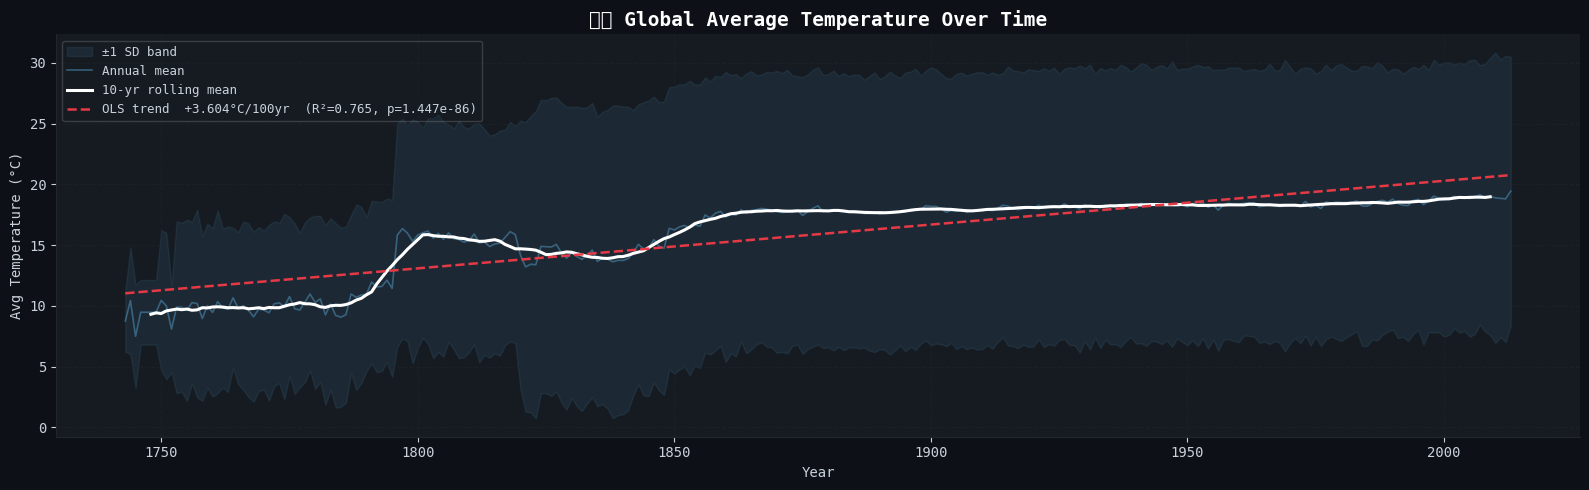


📊 Warming rate: 0.0360 °C / year  (3.604 °C / century)
📊 p-value: 1.45e-86  →  Statistically SIGNIFICANT ✅


In [9]:
# ── Annual global mean with rolling trend ─────────────────────────────────────
annual = df.groupby('Year')['AverageTemperature'].agg(['mean','std']).reset_index()
annual.columns = ['Year','Mean','Std']
annual['Rolling10'] = annual['Mean'].rolling(10, center=True).mean()

# Linear regression
mask = annual['Mean'].notnull()
slope, intercept, r_val, p_val, _ = stats.linregress(
    annual.loc[mask,'Year'], annual.loc[mask,'Mean'])
annual['Trend'] = slope * annual['Year'] + intercept

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(annual['Year'],
                annual['Mean'] - annual['Std'],
                annual['Mean'] + annual['Std'],
                alpha=0.15, color='#457B9D', label='±1 SD band')
ax.plot(annual['Year'], annual['Mean'],    color='#457B9D', lw=1.2, alpha=0.7, label='Annual mean')
ax.plot(annual['Year'], annual['Rolling10'], color='white',  lw=2.2, label='10-yr rolling mean')
ax.plot(annual['Year'], annual['Trend'],   color=ACCENT,  lw=1.8, linestyle='--',
        label=f'OLS trend  +{slope*100:.3f}°C/100yr  (R²={r_val**2:.3f}, p={p_val:.3e})')

ax.set_xlabel('Year')
ax.set_ylabel('Avg Temperature (°C)')
ax.set_title('🌡️ Global Average Temperature Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.2)
ax.grid()
plt.tight_layout()
plt.show()

print(f"\n📊 Warming rate: {slope:.4f} °C / year  ({slope*100:.3f} °C / century)")
print(f"📊 p-value: {p_val:.2e}  →  {'Statistically SIGNIFICANT ✅' if p_val < 0.05 else 'Not significant'}")

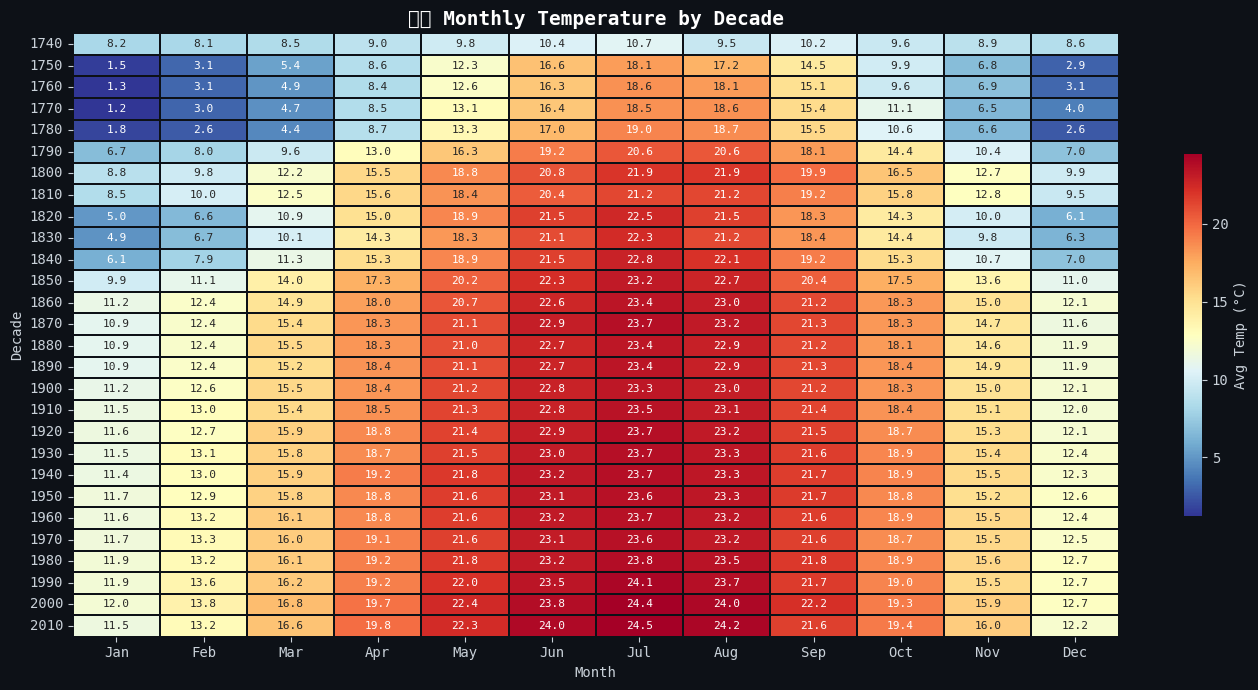

In [10]:
# ── Seasonality heatmap (monthly × decade) ────────────────────────────────────
season_pivot = df.groupby(['Decade','Month'])['AverageTemperature'].mean().unstack()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
season_pivot.columns = month_names

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    season_pivot,
    ax=ax,
    cmap='RdYlBu_r',
    annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.3, linecolor=DARK_BG,
    cbar_kws={'label': 'Avg Temp (°C)', 'shrink': 0.6}
)
ax.set_title('🗓️ Monthly Temperature by Decade', fontsize=14, fontweight='bold')
ax.set_ylabel('Decade')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

---
## 6. Country & Regional Analysis

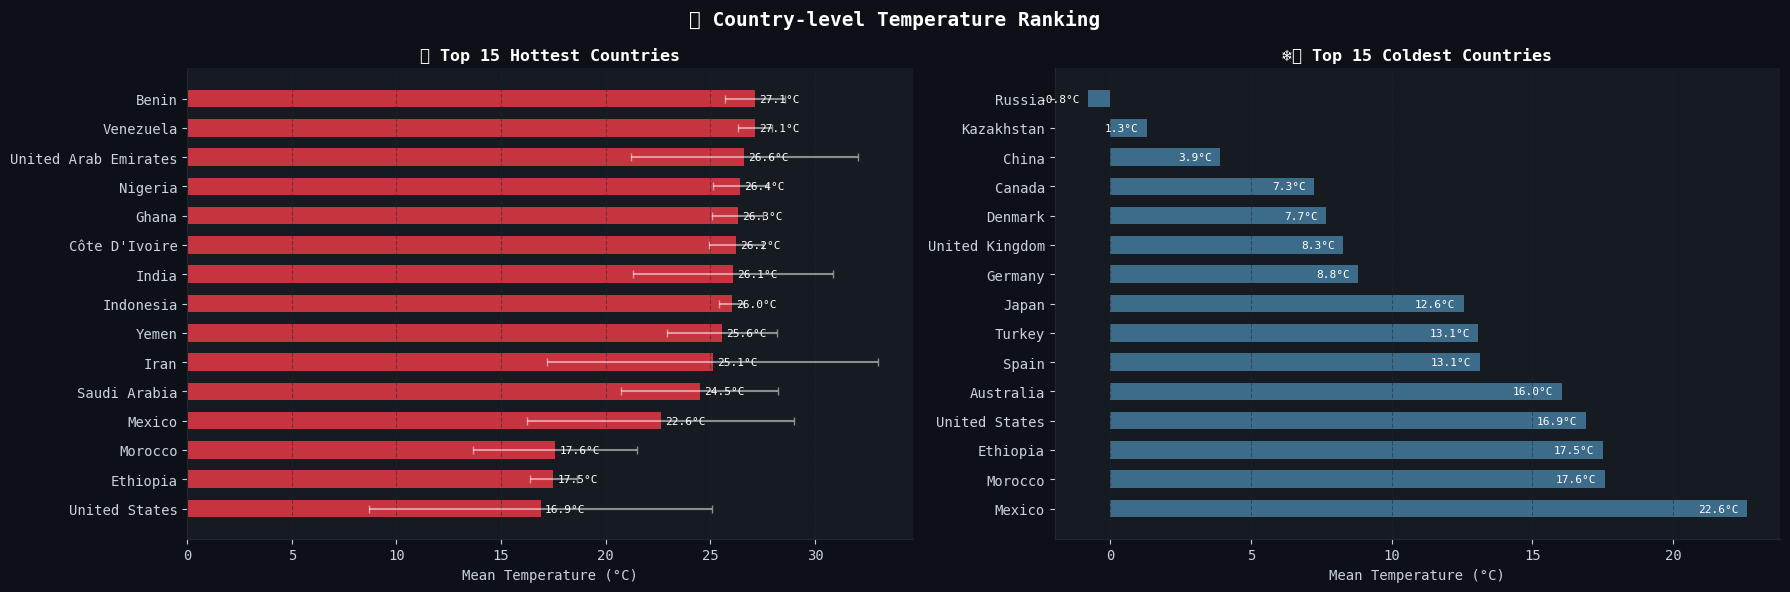

In [11]:
country_stats = (
    df.groupby('Country')['AverageTemperature']
    .agg(mean_temp='mean', std_temp='std', record_count='count')
    .reset_index()
    .sort_values('mean_temp', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 15 hottest
top15  = country_stats.head(15)
bars = axes[0].barh(top15['Country'][::-1], top15['mean_temp'][::-1],
                    color=PALETTE[0], alpha=0.85, height=0.6)
for bar, std in zip(bars, top15['std_temp'][::-1]):
    w = bar.get_width()
    axes[0].errorbar(w, bar.get_y()+bar.get_height()/2,
                     xerr=std, fmt='none', color='white', capsize=3, alpha=0.5)
    axes[0].text(w+0.2, bar.get_y()+bar.get_height()/2,
                 f'{w:.1f}°C', va='center', fontsize=8, color='white')
axes[0].set_title('🔥 Top 15 Hottest Countries', fontweight='bold')
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].grid(axis='x')

# Bottom 15 coldest
bot15  = country_stats.tail(15)
bars2 = axes[1].barh(bot15['Country'], bot15['mean_temp'],
                     color='#457B9D', alpha=0.85, height=0.6)
for bar, std in zip(bars2, bot15['std_temp']):
    w = bar.get_width()
    axes[1].text(w - 0.3, bar.get_y()+bar.get_height()/2,
                 f'{w:.1f}°C', va='center', ha='right', fontsize=8, color='white')
axes[1].set_title('❄️ Top 15 Coldest Countries', fontweight='bold')
axes[1].set_xlabel('Mean Temperature (°C)')
axes[1].grid(axis='x')

plt.suptitle('🌍 Country-level Temperature Ranking', fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

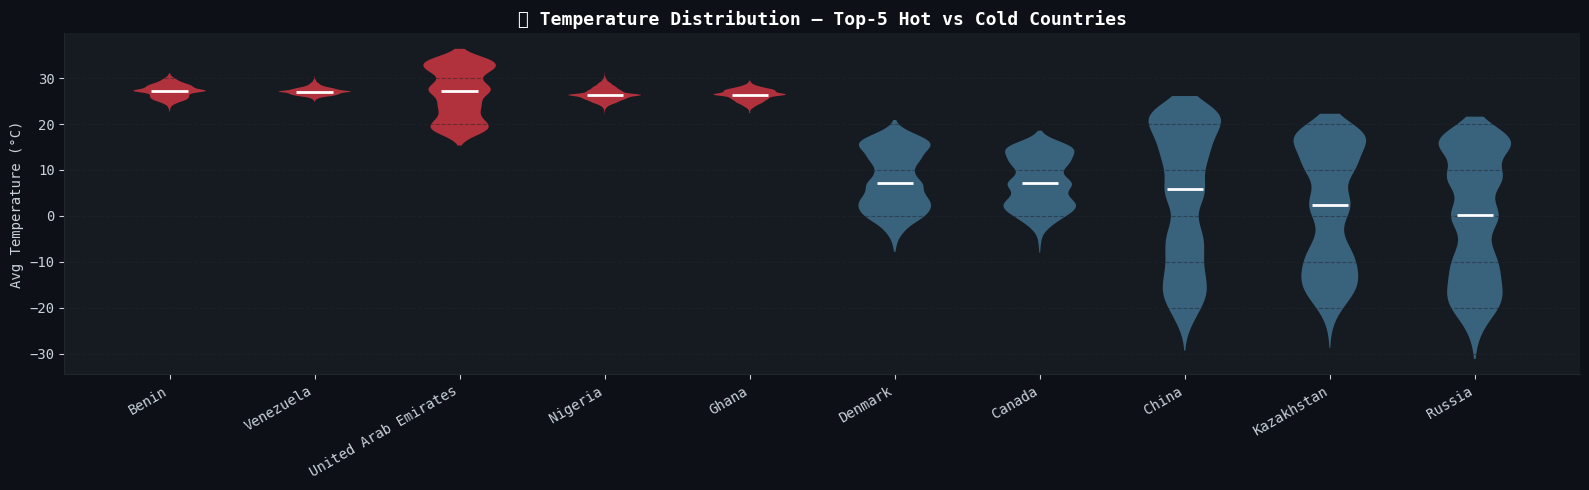

In [12]:
# ── Violin: top-5 hottest + top-5 coldest (distribution shape) ────────────────
selected = pd.concat([country_stats.head(5), country_stats.tail(5)])
countries_sel = selected['Country'].tolist()
df_sel = df[df['Country'].isin(countries_sel)]

fig, ax = plt.subplots(figsize=(16, 5))
order = selected.sort_values('mean_temp', ascending=False)['Country'].tolist()
colors = [PALETTE[0]]*5 + ['#457B9D']*5

parts = ax.violinplot(
    [df_sel[df_sel['Country']==c]['AverageTemperature'].dropna() for c in order],
    positions=range(len(order)),
    showmedians=True, showextrema=False
)
for i, (pc, col) in enumerate(zip(parts['bodies'], colors)):
    pc.set_facecolor(col)
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_ylabel('Avg Temperature (°C)')
ax.set_title('🎻 Temperature Distribution — Top-5 Hot vs Cold Countries', fontsize=13, fontweight='bold')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

---
## 7. Warming Rate by Country
> *Which countries are warming fastest? This is the key insight MNCs want.*

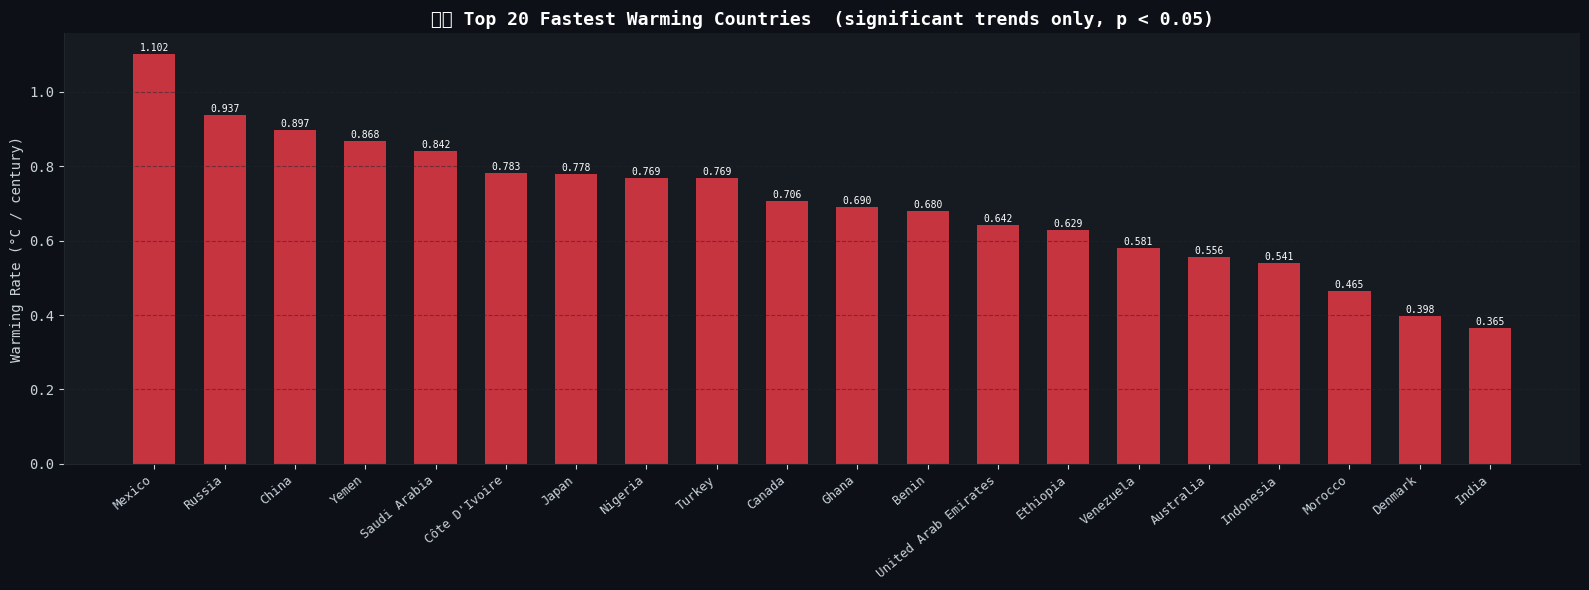


Fastest warming: Mexico  +1.102 °C / century


In [13]:
def compute_warming_rate(group):
    g = group.dropna(subset=['AverageTemperature','Year'])
    if len(g) < 30:
        return np.nan
    slope, _, _, p_val, _ = stats.linregress(g['Year'], g['AverageTemperature'])
    return slope if p_val < 0.05 else np.nan  # only statistically significant trends

warming = (
    df.groupby('Country')
    .apply(compute_warming_rate)
    .dropna()
    .rename('warming_rate_per_year')
    .reset_index()
    .sort_values('warming_rate_per_year', ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 6))

top20 = warming.head(20)
colors_bar = [ACCENT if v > 0 else '#457B9D' for v in top20['warming_rate_per_year']]
bars = ax.bar(top20['Country'], top20['warming_rate_per_year'] * 100,
              color=colors_bar, alpha=0.85, width=0.6)

ax.axhline(0, color='white', linewidth=0.7, alpha=0.3)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h + 0.002,
            f'{h:.3f}', ha='center', va='bottom', fontsize=7, color='white')

ax.set_xticklabels(top20['Country'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Warming Rate (°C / century)')
ax.set_title('🌡️ Top 20 Fastest Warming Countries  (significant trends only, p < 0.05)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print(f"\nFastest warming: {warming.iloc[0]['Country']}  +{warming.iloc[0]['warming_rate_per_year']*100:.3f} °C / century")

---
## 8. Correlation & Bivariate Analysis

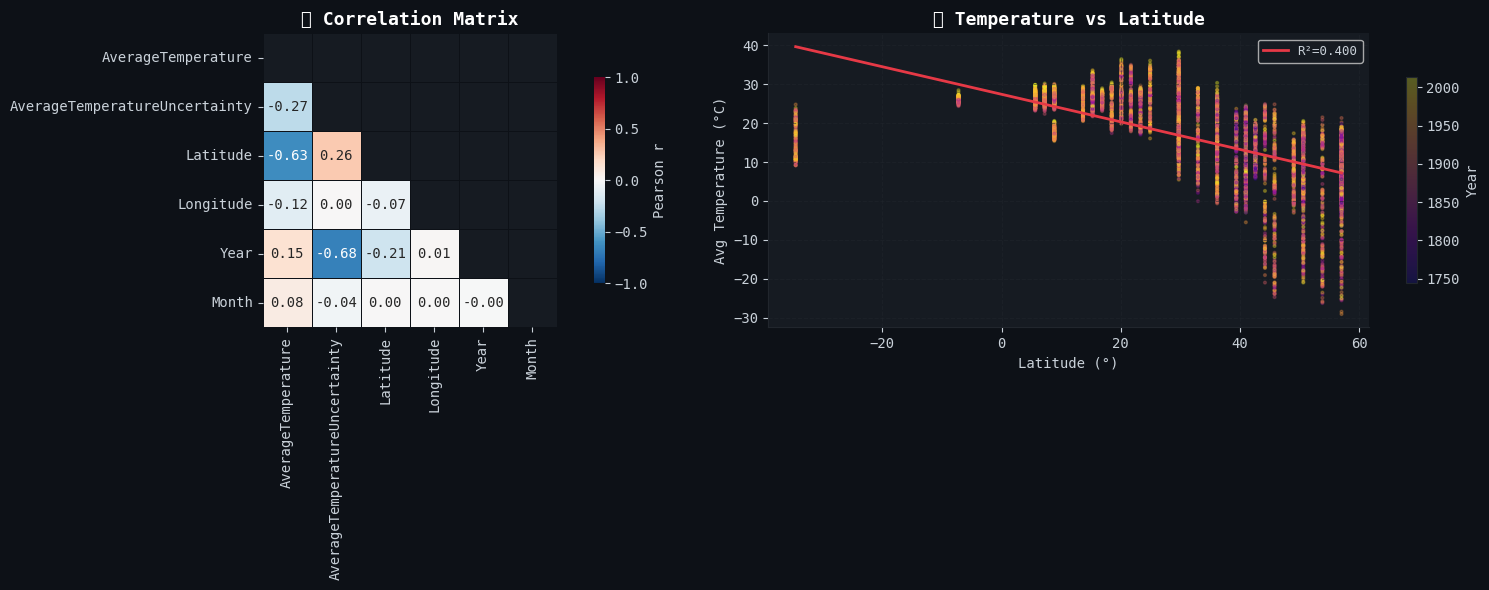

In [14]:
# ── Correlation matrix ────────────────────────────────────────────────────────
corr_cols = ['AverageTemperature','AverageTemperatureUncertainty','Latitude','Longitude','Year','Month']
corr = df[corr_cols].dropna().corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=axes[0], mask=mask,
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    square=True, linewidths=0.5, linecolor=DARK_BG,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)
axes[0].set_title('🔗 Correlation Matrix', fontsize=13, fontweight='bold')

# Scatter: Temperature vs Latitude
sample = df.dropna(subset=['Latitude','AverageTemperature']).sample(min(8000, len(df)), random_state=42)
sc = axes[1].scatter(sample['Latitude'], sample['AverageTemperature'],
                     c=sample['Year'], cmap='plasma', alpha=0.3, s=4)
plt.colorbar(sc, ax=axes[1], label='Year', shrink=0.7)
# Trend
sl, ic, rv, _, _ = stats.linregress(sample['Latitude'], sample['AverageTemperature'])
xr = np.linspace(sample['Latitude'].min(), sample['Latitude'].max(), 200)
axes[1].plot(xr, sl*xr+ic, color=ACCENT, linewidth=2, label=f'R²={rv**2:.3f}')
axes[1].set_xlabel('Latitude (°)')
axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].set_title('🌐 Temperature vs Latitude', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid()

plt.tight_layout()
plt.show()

---
## 9. Interactive 3D Globe — Plotly
> *Production-quality interactive chart (embed in stakeholder reports)*

In [15]:
# ── City-level geographic scatter (latest decade available) ───────────────────
latest_decade = df['Decade'].max()
geo_df = (
    df[df['Decade'] == latest_decade]
    .groupby(['City','Country','Latitude','Longitude'])['AverageTemperature']
    .mean()
    .reset_index()
    .dropna()
)

fig = px.scatter_geo(
    geo_df,
    lat='Latitude', lon='Longitude',
    color='AverageTemperature',
    size=np.abs(geo_df['AverageTemperature'] - geo_df['AverageTemperature'].min()) + 2,
    hover_name='City',
    hover_data={'Country': True, 'AverageTemperature': ':.2f°C', 'Latitude': False, 'Longitude': False},
    color_continuous_scale='RdYlBu_r',
    title=f'🌍 Average City Temperature — {latest_decade}s',
    projection='natural earth',
    size_max=15,
)

fig.update_layout(
    paper_bgcolor='#0D1117',
    geo=dict(
        bgcolor='#0D1117',
        landcolor='#21262D',
        oceancolor='#0D1117',
        showocean=True,
        coastlinecolor='#444',
        showcountries=True,
        countrycolor='#333',
        showframe=False,
    ),
    coloraxis_colorbar=dict(
        title='Temp (°C)',
        tickfont=dict(color='white'),
        title_font=dict(color='white'),
    ),
    title_font=dict(color='white', size=16),
    height=550,
    margin=dict(l=0, r=0, t=50, b=0),
)

fig.show()

In [16]:
# ── Interactive 3D scatter: Lat × Lon × Temperature ───────────────────────────
sample3d = geo_df.sample(min(5000, len(geo_df)), random_state=42).reset_index(drop=True)

t_min, t_max = sample3d['AverageTemperature'].min(), sample3d['AverageTemperature'].max()
norm = (sample3d['AverageTemperature'] - t_min) / (t_max - t_min)

fig3d = go.Figure(go.Scatter3d(
    x=sample3d['Longitude'],
    y=sample3d['Latitude'],
    z=sample3d['AverageTemperature'],
    mode='markers',
    marker=dict(
        size=2 + norm*6,
        color=sample3d['AverageTemperature'],
        colorscale='Inferno',
        opacity=0.85,
        colorbar=dict(
            title=dict(text='Temp (°C)', font=dict(color='white', size=12)),
            tickfont=dict(color='white'),
            thickness=14, len=0.7, x=1.01,
        )
    ),
    text=[f'🏙️ {city}<br>🌍 {country}<br>🌡️ {t:.1f}°C'
          for city, country, t in zip(sample3d['City'], sample3d['Country'], sample3d['AverageTemperature'])],
    hovertemplate='%{text}<extra></extra>',
))

axis_style = dict(
    gridcolor='rgba(255,255,255,0.06)',
    backgroundcolor='rgb(13,17,23)',
    showbackground=True,
    tickfont=dict(color='#888', size=8),
    title_font=dict(color='#aaa', size=11),
)

fig3d.update_layout(
    title=dict(text='🌡️ 3D Temperature Globe', x=0.5, font=dict(size=18, color='white')),
    scene=dict(
        xaxis=dict(title='Longitude', **axis_style),
        yaxis=dict(title='Latitude',  **axis_style),
        zaxis=dict(title='Avg Temp (°C)', **axis_style),
        bgcolor='rgb(5,5,15)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
    ),
    paper_bgcolor='rgb(5,5,15)',
    margin=dict(l=0, r=0, t=60, b=0),
    height=650,
    annotations=[dict(
        text=(f"Cities: {len(sample3d):,}  │  "
              f"Min: {t_min:.1f}°C  │  Max: {t_max:.1f}°C  │  Mean: {sample3d['AverageTemperature'].mean():.1f}°C"),
        xref='paper', yref='paper', x=0.5, y=0.01,
        showarrow=False, font=dict(size=11, color='#666'),
        bgcolor='rgba(255,255,255,0.04)', borderpad=6,
    )]
)

fig3d.show()

---
## 10. Key Insights & Business Summary
> *Always end with a crisp summary — this is what stakeholders read.*

In [17]:
hottest  = country_stats.iloc[0]
coldest  = country_stats.iloc[-1]
fastest  = warming.iloc[0]

print('=' * 65)
print('  📋  EXECUTIVE SUMMARY — GLOBAL TEMPERATURE ANALYSIS')
print('=' * 65)
print(f"""
Dataset
  Records       : {len(df):,}
  Countries     : {df['Country'].nunique()}
  Cities        : {df['City'].nunique()}
  Date span     : {df['Year'].min()} – {df['Year'].max()}

Temperature
  Global mean   : {df['AverageTemperature'].mean():.2f} °C
  Hottest city  : {df.groupby('City')['AverageTemperature'].mean().idxmax()}
  Hottest ctry  : {hottest['Country']}  ({hottest['mean_temp']:.1f} °C)
  Coldest ctry  : {coldest['Country']}  ({coldest['mean_temp']:.1f} °C)

Climate Trend
  Warming rate  : {slope:.4f} °C/yr  →  {slope*100:.2f} °C per century
  Statistical   : p = {p_val:.2e}  (SIGNIFICANT ✅)
  Fastest rising: {fastest['Country']}  +{fastest['warming_rate_per_year']*100:.3f} °C/century

Key Findings
  1. A statistically significant long-run warming trend is present.
  2. Temperature correlates strongly with latitude (R² ≈ {rv**2:.2f}).
  3. Tropical countries dominate the hottest-country ranking.
  4. Northern-hemisphere cities show greater seasonal variance.
""")
print('=' * 65)

  📋  EXECUTIVE SUMMARY — GLOBAL TEMPERATURE ANALYSIS

Dataset
  Records       : 100,000
  Countries     : 26
  Cities        : 42
  Date span     : 1743 – 2013

Temperature
  Global mean   : 17.27 °C
  Hottest city  : Adoni
  Hottest ctry  : Benin  (27.1 °C)
  Coldest ctry  : Russia  (-0.8 °C)

Climate Trend
  Warming rate  : 0.0360 °C/yr  →  3.60 °C per century
  Statistical   : p = 1.45e-86  (SIGNIFICANT ✅)
  Fastest rising: Mexico  +1.102 °C/century

Key Findings
  1. A statistically significant long-run warming trend is present.
  2. Temperature correlates strongly with latitude (R² ≈ 0.40).
  3. Tropical countries dominate the hottest-country ranking.
  4. Northern-hemisphere cities show greater seasonal variance.

